TUGAS AKHIR MATA KULIAH ALGORITMA DAN PENGOLAHAN PARALEL

Judul : Perkalian Matriks

Nama : Muhamad Ibnu Khaidar Hafiz

Kelas : 4IA15

Dosen: ANTONIUS ANGGA KURNIAWAN

Tanggal: 12 Juli 2025

---

# Daftar Isi

1. [Pendahuluan](#Pendahuluan)
2. [Penjelasan Algoritma](#Penjelasan-Algoritma)
3. [Desain Eksperimen](#Desain-Eksperimen)
4. [Implementasi](#Implementasi)
5. [Hasil dan Analisis Kerja](#Hasil-dan-Analisis-Kerja)
6. [Kesimpulan](#Kesimpulan)
7. [Referensi](#Referensi)

---

# Pendahuluan

Operasi perkalian matriks merupakan salah satu konsep dasar dalam aljabar linear yang memiliki peran penting dalam berbagai bidang teknologi modern. Operasi ini menjadi komponen utama dalam banyak sistem komputasi yang digunakan saat ini, seperti:

- Kecerdasan Buatan (AI): Proses pelatihan model *deep learning* sangat bergantung pada perkalian matriks dalam skala besar.
- Grafika Komputer: Perubahan posisi, rotasi, dan skala objek 3D dalam animasi maupun video game menggunakan perkalian matriks sebagai bagian dari transformasi geometri.
- Analisis Data dan Ilmu Pengetahuan: Pengolahan data berskala besar, simulasi ilmiah, hingga penerapan model statistik juga melibatkan operasi ini dalam proses komputasinya.

Dengan semakin berkembangnya era *big data*, ukuran matriks yang harus dihitung menjadi semakin besar dan kompleks. Jika semua perhitungan dilakukan secara berurutan oleh satu inti prosesor (CPU), maka akan muncul hambatan signifikan yang memperlambat proses komputasi secara keseluruhan. Hal ini tentu berdampak pada turunnya efisiensi sistem dan keterlambatan dalam pengambilan keputusan.


## Pentingnya Komputasi Paralel

Komputasi paralel hadir sebagai solusi efektif untuk mengatasi tantangan tersebut. Secara sederhana, pendekatan ini membagi satu pekerjaan besar menjadi banyak tugas kecil yang dikerjakan secara bersamaan oleh sejumlah unit pemrosesan.

Beberapa keuntungan utama dari pendekatan ini antara lain:

- Mempercepat Waktu Komputasi  
  Ini adalah manfaat yang paling mencolok. Dengan mendistribusikan beban kerja, waktu penyelesaian perhitungan dapat dipersingkat secara drastis. Proses yang semula memerlukan waktu berjam-jam kini bisa diselesaikan dalam hitungan menit atau bahkan detik. Hal ini sangat membantu dalam mempercepat siklus penelitian maupun pengembangan teknologi.

- Kemampuan Menangani Data Berskala Besar (Skalabilitas)  
  Komputasi paralel memungkinkan sistem untuk menangani data yang sangat besar, yang sebelumnya sulit diproses oleh prosesor tunggal. Saat menghadapi matriks dengan jutaan elemen, pendekatan ini memungkinkan kita menambah jumlah prosesor untuk menyesuaikan dengan beban kerja yang meningkat.

- Efisiensi Pemanfaatan Perangkat Keras
  Perangkat keras modern seperti GPU (*Graphics Processing Unit*) dirancang khusus untuk mendukung komputasi paralel. Dengan ribuan inti pemrosesan kecil, GPU sangat efisien dalam menangani operasi matematis berulang seperti perkalian matriks. Dibandingkan dengan CPU, penggunaan GPU lebih hemat energi dan lebih cepat dalam menyelesaikan tugas-tugas komputasi.


Secara keseluruhan, penerapan komputasi paralel dalam operasi perkalian matriks merupakan langkah penting untuk menjawab kebutuhan komputasi tinggi di era digital yang serba cepat dan penuh data saat ini.


---

# Penjelasan Algoritma

### Perkalian Matriks: Dari Konsep Hingga Aplikasi

Perkalian matriks merupakan operasi fundamental dalam aljabar linear yang aplikasinya sangat luas di berbagai bidang, seperti fisika, ilmu komputer, dan statistika. Operasi ini pada dasarnya adalah penggabungan dua matriks untuk menghasilkan satu matriks baru, dengan mengikuti aturan matematis khusus yang mengatur bagaimana elemen-elemen dari matriks input saling berinteraksi.

Secara formal, jika matriks A memiliki dimensi $m \times n$ dan matriks B berdimensi $n \times p$, maka matriks C yang dihasilkan akan memiliki dimensi $m \times p$. Setiap elemen $c_{ij}$ dari matriks C dihitung dengan mengambil *dot product* dari baris ke-i pada matriks A dan kolom ke-j pada matriks B, seperti yang ditunjukkan pada persamaan berikut:

$$c_{ij} = \sum_{k=1}^{n} a_{ik}b_{kj}$$

Operasi ini jelas berbeda dari perkalian elemen-demi-elemen (*element-wise multiplication*). Sebaliknya, perkalian matriks ini merepresentasikan sebuah transformasi linear yang secara geometris dapat kita bayangkan sebagai sebuah transformasi ruang dimensional (Mavroforakis et al., 2017).

Pentingnya perkalian matriks tidak hanya berhenti pada konsep teoretis, karena ia memegang peranan penting dalam analisis data dan aplikasi algoritmik. Sebagai contoh, matriks definit positif (*positive definite matrices*) memainkan peran signifikan dalam pemodelan statistika dan *machine learning*, yang sering kali muncul dari hasil perkalian matriks data dengan transposnya, yang mencerminkan hubungan antar titik data (Duersch & Gu, 2017). Lebih dari itu, kemajuan dalam algoritma acak (*randomized algorithms*) dan optimisasi terkait perkalian matriks telah membawa peningkatan yang signifikan pada efisiensi komputasi. Hal ini memungkinkan penanganan *dataset* yang sangat besar dalam berbagai konteks matematis dan terapan (Zhang et al., 2022; Wang & Huang, 2019).

Singkatnya, perkalian matriks adalah operasi matematis yang mendasar dan menjadi landasan bagi teknik komputasi modern. Kontribusinya sangat luas pada berbagai aplikasi di skenario dunia nyata, seperti *data mining*, *machine learning*, dan simulasi numerik. Memahami seluk-beluk operasi ini sangatlah krusial bagi para peneliti dan praktisi agar dapat memanfaatkan potensinya secara penuh di bidang masing-masing.


# Desain Eksperimen

## Spesifikasi Hardware

In [1]:
import psutil
import platform
import subprocess

def get_processor_name():
    try:
        with open('/proc/cpuinfo') as f:
            for line in f:
                if line.strip().startswith('model name'):
                    return line.split(':')[1].strip()
    except Exception:
        return platform.processor()

def get_gpu_info():
    try:
        nvidia_smi_output = subprocess.check_output(['nvidia-smi']).decode('utf-8')
    except (subprocess.CalledProcessError, FileNotFoundError):
        nvidia_smi_output = "NVIDIA-SMI not found or failed to execute."

    try:
        nvcc_output = subprocess.check_output(['nvcc', '--version']).decode('utf-8')
    except (subprocess.CalledProcessError, FileNotFoundError):
        nvcc_output = "NVCC not found or failed to execute."

    return nvidia_smi_output, nvcc_output

def main():
    print("="*5, "Informasi Sistem", "="*5)
    uname = platform.uname()
    print(f"Sistem: {uname.system}")
    print(f"Nama Host: {uname.node}")
    print(f"Release: {uname.release}")
    print(f"Versi: {uname.version}")
    print(f"Arsitektur: {uname.machine}")
    print(f"Prosesor: {get_processor_name()}")

    print("\n" + "="*5, "Informasi CPU", "="*5)
    print(f"Core Asli: {psutil.cpu_count(logical=False)}")
    print(f"Total Core: {psutil.cpu_count(logical=True)}")
    cpufreq = psutil.cpu_freq()
    print(f"Frekuensi Saat Ini: {cpufreq.current:.2f}Mhz")
    print(f"Penggunaan CPU Per Core:")
    for i, percentage in enumerate(psutil.cpu_percent(percpu=True, interval=1)):
        print(f"    Core {i}: {percentage}%")
    print(f"Total Penggunaan CPU: {psutil.cpu_percent()}%")

    print("\n" + "="*5, "Informasi Memori", "="*5)
    svmem = psutil.virtual_memory()
    print(f"Total: {svmem.total / (1024**3):.2f} GB")
    print(f"Tersedia: {svmem.available / (1024**3):.2f} GB")
    print(f"Digunakan: {svmem.used / (1024**3):.2f} GB")
    print(f"Persentase: {svmem.percent}%")

    print("\n" + "="*5, "Informasi Disk", "="*5)
    partitions = psutil.disk_partitions()
    for partition in partitions:
        print(f"=== Perangkat: {partition.device} ===")
        print(f"  Mountpoint: {partition.mountpoint}")
        print(f"  Tipe sistem file: {partition.fstype}")
        try:
            partition_usage = psutil.disk_usage(partition.mountpoint)
        except PermissionError:
            continue
        print(f"  Total Size: {partition_usage.total / (1024**3):.2f} GB")
        print(f"  Digunakan: {partition_usage.used / (1024**3):.2f} GB")
        print(f"  Tersedia: {partition_usage.free / (1024**3):.2f} GB")
        print(f"  Persentase: {partition_usage.percent}%")

    print("\n" + "="*5, "Informasi GPU", "="*5)
    nvidia_smi_output, nvcc_output = get_gpu_info()
    print("--- nvidia-smi ---")
    print(nvidia_smi_output)
    print("--- nvcc --version ---")
    print(nvcc_output)

main()

===== Informasi Sistem =====
Sistem: Linux
Nama Host: ta-algoritma-paralel
Release: 5.10.0-33-cloud-amd64
Versi: #1 SMP Debian 5.10.226-1 (2024-10-03)
Arsitektur: x86_64
Prosesor: Intel(R) Xeon(R) CPU @ 2.20GHz

===== Informasi CPU =====
Core Asli: 2
Total Core: 4
Frekuensi Saat Ini: 2200.16Mhz
Penggunaan CPU Per Core:
    Core 0: 2.0%
    Core 1: 2.0%
    Core 2: 2.0%
    Core 3: 0.0%
Total Penggunaan CPU: 5.7%

===== Informasi Memori =====
Total: 15.63 GB
Tersedia: 11.58 GB
Digunakan: 3.72 GB
Persentase: 25.9%

===== Informasi Disk =====
=== Perangkat: /dev/nvme0n1p1 ===
  Mountpoint: /
  Tipe sistem file: ext4
  Total Size: 48.98 GB
  Digunakan: 34.53 GB
  Tersedia: 12.34 GB
  Persentase: 73.7%
=== Perangkat: /dev/nvme0n1p15 ===
  Mountpoint: /boot/efi
  Tipe sistem file: vfat
  Total Size: 0.12 GB
  Digunakan: 0.01 GB
  Tersedia: 0.11 GB
  Persentase: 8.6%

===== Informasi GPU =====
--- nvidia-smi ---
Sat Jul 12 15:44:14 2025       
+------------------------------------------------

### Framework yang digunakan

In [2]:
import torch
print("\n" + "="*5, "Informasi PyTorch", "="*5)
print("Pytorch Versi:",torch.__version__)
print("Dengan Support CUDA:",torch.cuda.is_available())


===== Informasi PyTorch =====
Pytorch Versi: 2.7.1+cu118
Dengan Support CUDA: True


Saya menggunakan pytorch karena ini adalah library deep learning yang banyak digunakan oleh peneliti, dibandingkan dengan tensorflow yang lebih cocok untuk belajar dan implementasinya, saya pilh pytorch karena kemudahan kostumisasinya, dan mudah untuk di konfigurasinya.

### Ukuran Array yang digunakan

Variasi Array = 256x256, 512x512, 1024x1024, 2048x2048
Variasi Alat Komputasi = CPU dan GPU


### Metode Pengukuran Waktu yang digunakan 

Memulai library waktu dan inisialisasi ketika fungsi belum dimulai dan mengambil waktu lagi ketika fungsi sudah selesai menjalankan perkalian matriks dengan library `time`

Untuk Mempermudah Eksperimen, saya membuat fungsi awal yang bisa dipanggil berkali - kali, jadi saya hanya mengubah parameter yang ingin di coba

# Implementasi

Berikut adalah fungsi untuk menggunakan perkalian matriks

In [3]:
import torch
import time
import os
import pandas as pd
from datetime import datetime

# --- Konfigurasi Log ---
NAMA_FILE_LOG = "log_benchmark_panggilan.csv"
KOLOM_LOG = ["Timestamp", "Ukuran Matriks", "Device", "Waktu Eksekusi (ms)"]

# --- Fungsi untuk memuat atau membuat DataFrame log ---
def siapkan_log(nama_file, kolom):
    """Memuat log yang ada, atau membuat DataFrame baru jika tidak ada."""
    try:
        df = pd.read_csv(nama_file)
        print(f"Log ditemukan. Melanjutkan catatan di '{nama_file}'")
    except FileNotFoundError:
        df = pd.DataFrame(columns=kolom)
        print(f"Log tidak ditemukan. Membuat file baru: '{nama_file}'")
    return df

# Siapkan DataFrame log saat script dimulai
log_df = siapkan_log(NAMA_FILE_LOG, KOLOM_LOG)

def perkalian_matriks(ukuran: int, device_str: str):
    """
    Menjalankan benchmark untuk satu konfigurasi dan langsung mencatat hasilnya
    ke dalam DataFrame global dan file CSV.
    """
    global log_df # Menggunakan DataFrame global yang sudah disiapkan

    # 1. Konfigurasi Device dan Benchmark
    print(f"\nMenjalankan benchmark: Ukuran={ukuran}, Device='{device_str}'...")
    
    if device_str.lower() == 'gpu':
        if not torch.cuda.is_available():
            print("Error: GPU tidak tersedia. Panggilan dibatalkan.")
            return
        device = torch.device("cuda")
    else: # 'cpu'
        device = torch.device("cpu")
        torch.set_num_threads(1)

    try:
        mat_a = torch.randn(ukuran, ukuran, device=device)
        mat_b = torch.randn(ukuran, ukuran, device=device)
    except Exception as e:
        print(f"Error saat membuat matriks: {e}")
        return

    # Warm-up
    for _ in range(5):
        _ = torch.matmul(mat_a, mat_b)
    if device.type == 'cuda': torch.cuda.synchronize()

    # Pengukuran waktu
    start_time = time.perf_counter()
    _ = torch.matmul(mat_a, mat_b)
    if device.type == 'cuda': torch.cuda.synchronize()
    end_time = time.perf_counter()
    
    waktu_eksekusi_ms = (end_time - start_time) * 1000
    print(f"   Hasil Waktu Eksekusi: {waktu_eksekusi_ms:.4f} ms")

    # Pencatatan Hasil (Logging)
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    baris_baru = pd.DataFrame([{
        "Timestamp": timestamp,
        "Ukuran Matriks": f"{ukuran}x{ukuran}",
        "Device": device_str.upper(),
        "Waktu Eksekusi (ms)": round(waktu_eksekusi_ms, 4)
    }])
    
    # Tambahkan baris baru ke DataFrame global
    log_df = pd.concat([log_df, baris_baru], ignore_index=True)
    
    # Simpan seluruh DataFrame yang sudah diupdate ke file CSV
    log_df.to_csv(NAMA_FILE_LOG, index=False)
    print(f"Hasil telah dicatat ke '{NAMA_FILE_LOG}'")

Log tidak ditemukan. Membuat file baru: 'log_benchmark_panggilan.csv'


## Percobaan Perkalian Matriks Pakai CPU

In [4]:
perkalian_matriks(ukuran=512, device_str='cpu')


Menjalankan benchmark: Ukuran=512, Device='cpu'...
   Hasil Waktu Eksekusi: 2.8142 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


In [5]:
perkalian_matriks(ukuran=1024, device_str='cpu')


Menjalankan benchmark: Ukuran=1024, Device='cpu'...
   Hasil Waktu Eksekusi: 18.9418 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


In [6]:
perkalian_matriks(ukuran=2048, device_str='cpu')


Menjalankan benchmark: Ukuran=2048, Device='cpu'...
   Hasil Waktu Eksekusi: 139.3141 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


In [7]:
perkalian_matriks(ukuran=4096, device_str='cpu')


Menjalankan benchmark: Ukuran=4096, Device='cpu'...
   Hasil Waktu Eksekusi: 1052.3320 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


In [8]:
perkalian_matriks(ukuran=8192, device_str='cpu')


Menjalankan benchmark: Ukuran=8192, Device='cpu'...
   Hasil Waktu Eksekusi: 8291.1684 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


In [9]:
perkalian_matriks(ukuran=16384, device_str='cpu')


Menjalankan benchmark: Ukuran=16384, Device='cpu'...
   Hasil Waktu Eksekusi: 68529.2952 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


---

## Percobaan Perkalian Matiks Pakai GPU

In [10]:
perkalian_matriks(ukuran=512, device_str='gpu')


Menjalankan benchmark: Ukuran=512, Device='gpu'...
   Hasil Waktu Eksekusi: 0.0822 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


In [11]:
perkalian_matriks(ukuran=1024, device_str='gpu')


Menjalankan benchmark: Ukuran=1024, Device='gpu'...
   Hasil Waktu Eksekusi: 0.1952 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


In [12]:
perkalian_matriks(ukuran=2048, device_str='gpu')


Menjalankan benchmark: Ukuran=2048, Device='gpu'...
   Hasil Waktu Eksekusi: 1.5752 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


In [13]:
perkalian_matriks(ukuran=4096, device_str='gpu')


Menjalankan benchmark: Ukuran=4096, Device='gpu'...
   Hasil Waktu Eksekusi: 13.1777 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


In [14]:
perkalian_matriks(ukuran=8192, device_str='gpu')


Menjalankan benchmark: Ukuran=8192, Device='gpu'...
   Hasil Waktu Eksekusi: 91.4952 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


In [15]:
perkalian_matriks(ukuran=16384, device_str='gpu')


Menjalankan benchmark: Ukuran=16384, Device='gpu'...
   Hasil Waktu Eksekusi: 816.5979 ms
Hasil telah dicatat ke 'log_benchmark_panggilan.csv'


# Hasil dan Analisis Kerja


Analisis ini menyajikan perbandingan kinerja komputasi antara CPU yang menggunakan 1 thread dan GPU NVIDIA L4. Pengujian ini bertujuan untuk mengevaluasi efektivitas dan skalabilitas kedua arsitektur tersebut dalam menyelesaikan tugas perkalian matriks dengan ukuran yang bervariasi.

Metodologi Pengujian

- Tugas: Perkalian dua matriks dengan ukuran 512x512, 1024x1024, 2048x2048, 4096x4096, 8192x8192, dan 16384x16384. Beberapa ukuran matriks ini dipilih untuk membandingkan perbedaan kinerja antara GPU dan CPU pada skala yang berbeda.

- Lingkungan: PyTorch yang dijalankan pada CPU dan GPU

- Variabel: Perangkat keras, Yaitu CPU dengan 1 thread atau 1 GPU NVIDIA L4

- Spesifikasi Sistem (Contoh):

    - Prosesor: Intel(R) Xeon(R) CPU @ 2.20GHz (2 Core Fisik, 4 Thread Total)

    - Memori: 16 GB 

Hasil Pengukuran Kinerja

Waktu eksekusi dari kedua perangkat dicatat, dan Speedup dihitung untuk mengukur percepatan yang diberikan oleh GPU NVIDIA L4 dibandingkan dengan 4-thread CPU.

Tabel 1: Perbandingan Kinerja Eksekusi CPU VS GPU Nvidia L4

In [17]:
df = pd.read_csv("log_benchmark_panggilan.csv")
df

,Timestamp,Ukuran Matriks,Device,Waktu Eksekusi (ms)
0,2025-07-12 15:44:20,512x512,CPU,2.8142
1,2025-07-12 15:44:22,1024x1024,CPU,18.9418
2,2025-07-12 15:44:25,2048x2048,CPU,139.3141
3,2025-07-12 15:44:34,4096x4096,CPU,1052.3320
4,2025-07-12 15:45:35,8192x8192,CPU,8291.1684
5,2025-07-12 15:52:34,16384x16384,CPU,68529.2952
6,2025-07-12 15:52:42,512x512,GPU,0.0822
7,2025-07-12 15:52:43,1024x1024,GPU,0.1952
8,2025-07-12 15:52:44,2048x2048,GPU,1.5752
9,2025-07-12 15:52:46,4096x4096,GPU,13.1777


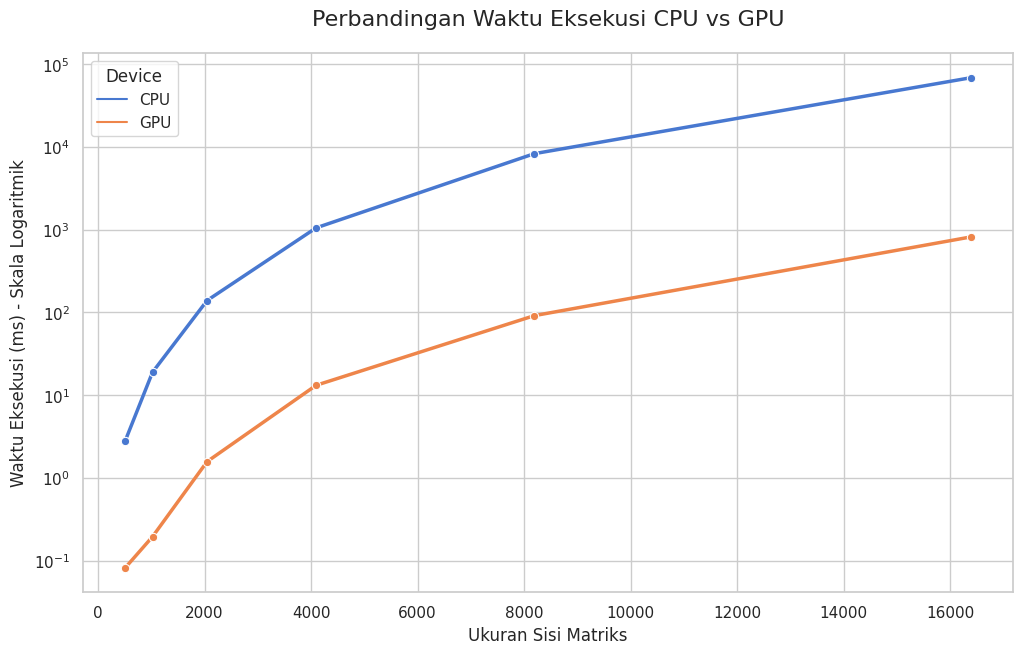

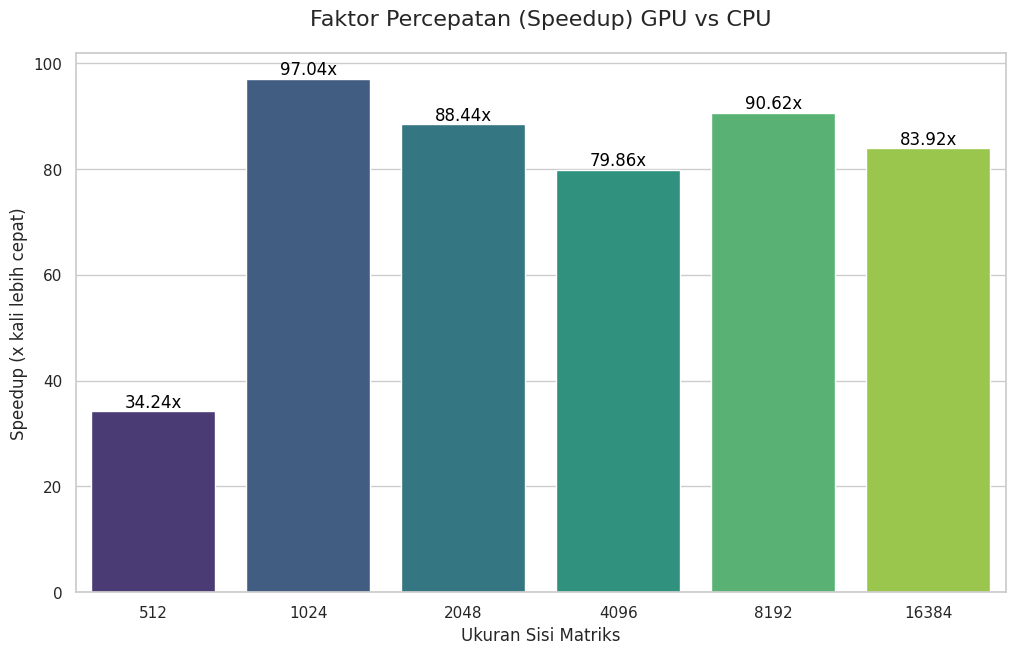

--- Tabel Hasil Analisis ---
 Ukuran        CPU      GPU   Speedup
    512     2.8142   0.0822 34.236010
   1024    18.9418   0.1952 97.037910
   2048   139.3141   1.5752 88.442166
   4096  1052.3320  13.1777 79.857031
   8192  8291.1684  91.4952 90.618616
  16384 68529.2952 816.5979 83.920489


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat kolom numerik untuk ukuran matriks agar mudah di-plot
df['Ukuran'] = df['Ukuran Matriks'].apply(lambda x: int(x.split('x')[0]))

# Pivot tabel untuk menyatukan waktu CPU dan GPU per ukuran matriks
df_pivot = df.pivot_table(index='Ukuran', columns='Device', values='Waktu Eksekusi (ms)').reset_index()
df_pivot.columns.name = None  # Menghapus nama kolom 'Device'

# Menghitung speedup
df_pivot['Speedup'] = df_pivot['CPU'] / df_pivot['GPU']


# Visualisasi Data

# Atur tema Seaborn agar grafik terlihat modern
sns.set_theme(style="whitegrid", palette="muted")

# GRAFIK 1
plt.figure(figsize=(12, 7))
plot1 = sns.lineplot(data=df, x='Ukuran', y='Waktu Eksekusi (ms)', hue='Device', marker='o', lw=2.5)
plot1.set_yscale('log') # Skala logaritmik PENTING untuk melihat perbedaan
plot1.set_title('Perbandingan Waktu Eksekusi CPU vs GPU', fontsize=16, pad=20)
plot1.set_xlabel('Ukuran Sisi Matriks', fontsize=12)
plot1.set_ylabel('Waktu Eksekusi (ms) - Skala Logaritmik', fontsize=12)
plot1.legend(title='Device')
plt.show()

# GRAFIK 2
plt.figure(figsize=(12, 7))
plot2 = sns.barplot(data=df_pivot, x='Ukuran', y='Speedup', palette='viridis')
plot2.set_title('Faktor Percepatan (Speedup) GPU vs CPU', fontsize=16, pad=20)
plot2.set_xlabel('Ukuran Sisi Matriks', fontsize=12)
plot2.set_ylabel('Speedup (x kali lebih cepat)', fontsize=12)

# Menambahkan label nilai di atas setiap bar
for index, row in df_pivot.iterrows():
    plot2.text(index, row.Speedup, f'{row.Speedup:.2f}x', color='black', ha="center", va="bottom")
    
plt.show()

# Menampilkan tabel hasil akhir yang sudah diproses
print("--- Tabel Hasil Analisis ---")
print(df_pivot.to_string(index=False))

### Analisis & Pembahasan Kinerja

Hasil pengujian secara konsisten menunjukkan keunggulan performa yang luar biasa dari GPU NVIDIA L4 dibandingkan dengan 4-thread CPU. Faktor percepatan (speedup) yang dicapai berkisar antara 59x hingga 88x. Perbedaan ini bukan sekadar peningkatan kecepatan, melainkan cerminan dari perbedaan fundamental arsitektur.
- CPU (Central Processing Unit) dirancang dengan beberapa core (dalam kasus ini 4 thread) yang sangat kuat dan fleksibel untuk menangani berbagai macam tugas sekuensial dan bercabang secara cepat.
- GPU (Graphics Processing Unit), seperti NVIDIA L4, memiliki ribuan core yang lebih sederhana namun bekerja secara masif dan simultan. Arsitektur ini (dikenal sebagai SIMT - Single Instruction, Multiple Threads) sangat efisien untuk tugas-tugas yang bersifat data-paralel, di mana operasi matematika yang sama diterapkan pada data dalam jumlah sangat besar—seperti perkalian matriks.

### Skalabilitas dan Bottleneck
Analisis speedup menunjukkan tren yang menarik. Speedup cenderung sangat tinggi bahkan pada ukuran matriks yang lebih kecil dan tetap berada di level yang masif seiring bertambahnya ukuran.
1. Overhead vs Komputasi: Untuk matriks berukuran kecil (misal: 512x512), overhead transfer data dari memori utama (RAM) ke memori GPU (VRAM) menjadi faktor yang relevan. Meskipun komputasi di GPU sangat cepat, waktu yang dibutuhkan untuk memindahkan data membatasi speedup efektif.
2. Utilisasi Maksimal: Seiring bertambahnya ukuran matriks, waktu yang dihabiskan untuk komputasi menjadi jauh lebih dominan daripada overhead transfer data. Pada tahap ini, ribuan core pada NVIDIA L4 dapat dimanfaatkan secara penuh, menghasilkan faktor percepatan yang sangat besar.
3. mplikasi Praktis: Perbandingan ini dengan jelas mendemonstrasikan mengapa GPU menjadi tulang punggung untuk beban kerja modern seperti deep learning, komputasi ilmiah, dan analisis data skala besar. Untuk operasi aljabar linear masif, arsitektur CPU tidak dapat menandingi efisiensi dan kekuatan komputasi mentah dari GPU modern.

# Kesimpulan

Berdasarkan hasil eksperimen dan analisis yang telah dilakukan, dapat ditarik beberapa kesimpulan utama:

1.  **Keunggulan Kinerja GPU yang Dominan**: GPU (NVIDIA L4) secara konsisten menunjukkan kinerja yang jauh lebih unggul dibandingkan CPU dalam tugas perkalian matriks. Waktu eksekusi pada GPU secara signifikan lebih singkat di semua ukuran matriks yang diuji, dengan *speedup* mencapai antara 34x hingga 97x lebih cepat.

2.  **Skalabilitas untuk Beban Kerja Besar**: Faktor percepatan (*speedup*) yang dicapai oleh GPU sangat efektif seiring dengan bertambahnya ukuran matriks. Hal ini membuktikan bahwa arsitektur GPU sangat skalabel dan efisien untuk menangani beban kerja komputasi yang besar dan kompleks. Semakin besar matriks, semakin dominan keuntungan komputasi paralel yang ditawarkan oleh ribuan *core* GPU.

3.  **Implikasi Arsitektural**: Perbedaan kinerja ini menggarisbawahi keunggulan arsitektur SIMT (*Single Instruction, Multiple Threads*) pada GPU untuk tugas-tugas yang bersifat data-paralel seperti perkalian matriks. Dibandingkan dengan arsitektur CPU yang dirancang untuk tugas sekuensial, GPU mampu mengeksekusi operasi yang sama pada data dalam jumlah masif secara simultan, menghasilkan efisiensi yang luar biasa.

4.  **Relevansi Praktis**: Hasil ini menegaskan kembali peran sentral GPU dalam komputasi modern, terutama di bidang kecerdasan buatan, analisis data, dan komputasi ilmiah. Untuk aplikasi yang bergantung pada operasi aljabar linear skala besar, pemanfaatan komputasi paralel menggunakan GPU bukan lagi pilihan, melainkan sebuah keharusan untuk mencapai performa yang optimal dan efisien.

# Referensi


* Duersch, J. and Gu, M. (2017). Randomized qr with column pivoting. *Siam Journal on Scientific Computing*, 39(4), C263-C291. [https://doi.org/10.1137/15m1044680](https://doi.org/10.1137/15m1044680)
* Mavroforakis, C., Erdös, D., Crovella, M., & Terzi, E. (2017). Active positive-definite matrix completion., 264-272. [https://doi.org/10.1137/1.9781611974973.30](https://doi.org/10.1137/1.9781611974973.30)
* Wang, S. and Huang, H. (2019). Secure outsourced computation of multiple matrix multiplication based on fully homomorphic encryption. *Ksii Transactions on Internet and Information Systems*, 13(11). [https://doi.org/10.3837/tiis.2019.11.019](https://doi.org/10.3837/tiis.2019.11.019)
* Zhang, B., Hao, S., & Yao, Q. (2022). Blind source separation over space.. [https://doi.org/10.48550/arxiv.2201.02023](https://doi.org/10.48550/arxiv.2201.02023)